In [452]:
import torch
import torch.nn as nn 
import shutil, glob
import torch.optim as optim 
from torch.utils.data import  DataLoader
from torch.utils.tensorboard import SummaryWriter
from torchvision.datasets import ImageFolder
from torchvision import transforms , models
from data_transform import offset_crop, LoadUint16TIff, customVal, CustomDataset ,sample_gaussian_in_range, clip, gamma_enh
import os 
import numpy as np
import matplotlib.pyplot as plt 
from PIL import Image
import cv2

In [453]:
# HyperParameters and Directory 

train_dir = "bomber_figther_helicopter/train"
val_dir = "bomber_figther_helicopter/val"
checkpoint_dir = "checkpoint_BFHT"
batch_size = 64
learning_rate = 51e-5
num_classes =4
num_epochs = 100
checkpoint_name = f"standard_val_BFHT_{num_epochs}_{batch_size}_dropout0.35_weight_decay_ema"
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
writer = SummaryWriter(f"BFHT/standard_val_CBH_test2_{num_epochs}_{batch_size}_dropout0.35_weight_decay_ema")

In [536]:
#  Augmentation
def mig_aug_train(gamma_stretch=[0.4, 0.8], mul = [3,6],additive = [0.3, 1]):
    def augmentation(img):
        arr = img.numpy()
        arr = (arr-arr.min())/(arr.max()- arr.min())
        gst= sample_gaussian_in_range(np.array(gamma_stretch).mean(), 1.5, gamma_stretch[0], gamma_stretch[1])
        add = sample_gaussian_in_range(np.array(additive).mean(), 1.5, additive[0], additive[-1])
        mul_val = sample_gaussian_in_range(np.array(mul).mean(), 1.5, low= mul[0], high=mul[1])
        arr = clip(gamma_enh(arr,gst)+np.random.gamma(add, 1/20, arr.shape), min = 5, max = 99.25)
        if arr.ndim ==2:
            arr = np.stack([arr, arr, arr], axis= 0)
        img_out = torch.from_numpy(arr.astype(np.float32))
        return img_out

    return augmentation


def tu_aug_train(paraml =[0.7,1], g_enh=[0.4, 0.8], clutter=[1.2,3]):
    def apply_gamma(img):
        arr = img.numpy()
        arr /= arr.max()

        param = sample_gaussian_in_range((paraml[0]+paraml[1])/2, 1.5, low = paraml[0], high=paraml[-1])
        enh = sample_gaussian_in_range((g_enh[0]+g_enh[1])/2, 1.5,low= g_enh[0], high=g_enh[-1])
        cl = sample_gaussian_in_range((clutter[0]+clutter[1])/2, 1.5, clutter[0], clutter[-1])
        
        cl_denom = sample_gaussian_in_range(15,sigma=1.5,low = 10, high=20)
        arr = clip(gamma_enh(arr*np.random.gamma(param, 1/20),enh, arr.shape) + np.random.gamma(cl, 1/20, arr.shape), min = 0.1)
        if arr.ndim == 2:
            arr = np.stack([arr,arr, arr], axis = 0)
        img_out = torch.from_numpy(arr.astype(np.float32))
        return img_out
    return apply_gamma
def civil_aug_train(mgam1 = [0.5, 0.8], mgam2=[20, 70], cl = [0.3, 0.8], agamma1= [0.3, 0.8], agamma2=[15,30]):
    def augmentation(img):
        arr = img.numpy()
        arr = (arr-arr.min())/(arr.max()- arr.min())
        mgam1_val = sample_gaussian_in_range(np.array(mgam1).mean(), 1.5, mgam1[0], mgam1[-1])
        mgam2_val = sample_gaussian_in_range(np.array(mgam2).mean(),1.5, mgam2[0], mgam2[-1])
        agamma1_val = sample_gaussian_in_range(np.array(agamma1).mean(), 1.5, agamma1[0], agamma1[-1])
        agamma2_val = sample_gaussian_in_range(np.array(agamma2).mean(), 1.5, agamma2[0], agamma2[-1])
        cl_val = sample_gaussian_in_range(np.array(cl).mean(), 1.5, cl[0], cl[1])
        arr = clip(gamma_enh(arr*np.random.gamma(mgam1_val, 1/mgam2_val), cl_val) + np.random.gamma(agamma1_val, 1/agamma2_val,arr.shape),min = 10, max = 98)
        arr = arr
        if arr.ndim ==2:
            arr = np.stack([arr, arr, arr], axis = 0)
        img_out = torch.from_numpy(arr.astype(np.float32))
        return img_out
    return augmentation

#mgam1 = [3,6] agamma = [3,7]
def hel_aug_train(mgam1 = [0.6,2], mgam2=[15,20], agamma1= [3,7], agamma2=[40,70], cl= [0.3, 0.8]):
    def augmentation(img):
        arr = img.numpy()
        arr = (arr-arr.min())/(arr.max()- arr.min())
        mgam1_val = sample_gaussian_in_range(np.array(mgam1).mean(), 1.5, mgam1[0], mgam1[-1])
        mgam2_val = sample_gaussian_in_range(np.array(mgam2).mean(),1.5, mgam2[0], mgam2[-1])
        agamma1_val = sample_gaussian_in_range(np.array(agamma1).mean(), 1.5, agamma1[0], agamma1[-1])
        agamma2_val = sample_gaussian_in_range(np.array(agamma2).mean(), 1.5, agamma2[0], agamma2[-1])
        # cv2.resize(clip(gamma(sim* np.random.gamma(4,1/20,sim.shape),0.8) + np.random.gamma(.6, 1/20, sim.shape), min=1,max = 99.25),None, fx = 1, fy =1, interpolation =cv2.INTER_AREA)
        arr = clip(gamma_enh(arr*np.random.gamma(mgam1_val, 1/mgam2_val), 0.4) + np.random.gamma(agamma1_val, 1/agamma2_val,arr.shape),min = 0.5, max = 99.25)
        arr = arr
        if arr.ndim ==2:
            arr = np.stack([arr, arr, arr], axis = 0)
        img_out = torch.from_numpy(arr.astype(np.float32))
        return img_out
    return augmentation



def transporter_aug_train(mgam1 = [0.5,1.1], mgam2=[20, 70], cl = [0.3, 0.7], agamma1= [0.5,1.8], agamma2=[10,80]):
    def augmentation(img):
        arr = img.numpy()
        arr = (arr-arr.min())/(arr.max()- arr.min())
        mgam1_val = sample_gaussian_in_range(np.array(mgam1).mean(), 1.5, mgam1[0], mgam1[-1])
        mgam2_val = sample_gaussian_in_range(np.array(mgam2).mean(),1.5, mgam2[0], mgam2[-1])
        agamma1_val = sample_gaussian_in_range(np.array(agamma1).mean(), 1.5, agamma1[0], agamma1[-1])
        agamma2_val = sample_gaussian_in_range(np.array(agamma2).mean(), 1.5, agamma2[0], agamma2[-1])
        cl_val = sample_gaussian_in_range(np.array(cl).mean(), 1.5, cl[0], cl[1])
        arr = clip(gamma_enh(arr*np.random.gamma(mgam1_val, 1/mgam2_val), cl_val) + np.random.gamma(agamma1_val, 1/agamma2_val,arr.shape),min = 1, max = 99.5)
        arr = arr
        if arr.ndim ==2:
            arr = np.stack([arr, arr, arr], axis = 0)
        img_out = torch.from_numpy(arr.astype(np.float32))
        return img_out
    return augmentation

In [537]:
from torch.utils.data import Dataset

class CustomDataset(Dataset):
    def __init__(self, root_dir,class_transforms):
        self.data = ImageFolder(root=root_dir)
        self.class_transform = class_transforms

        self.class_to_idx = self.data.class_to_idx
        self.labels_name = list(self.class_to_idx.keys())
        # pdb.set_trace()
    def __len__(self):
        return len(self.data)
    
    def __getitem__(self, idx):
        img_path, label = self.data.samples[idx]
        image = Image.open(img_path).convert('RGB')
        key = self.labels_name[label]
        if key in self.class_transform:
            transform = self.class_transform[key]
            image = transform(image)
        else:
            print(f"Warning: NO specific transform found for class {key}. Applying default")
            image = transforms.Compose([transforms.ToTensor(),
                                        transforms.Normalize(mean=[0.485,0.456,0.406],std = [0.229, 0.224, 0.225])])
            

        return image, label

In [538]:

train_class_transform= {"fighter": transforms.Compose([transforms.Lambda(lambda img: offset_crop(img)(img)),
                                    transforms.ToTensor(),
                                    transforms.Lambda(mig_aug_train()),
                                    transforms.Normalize(mean = [0.485, 0.456, 0.406],std = [0.229, 0.224,0.225])]),
                        "Tu_95": transforms.Compose([transforms.Lambda(lambda img: offset_crop(img, crop_size=95)(img)),
                                    transforms.ToTensor(), 
                                    transforms.Lambda(tu_aug_train()),
                                    transforms.Normalize(mean=[0.485,0.456,0.406], std = [0.229, 0.224, 0.225])]),
                        
                        "helicopter": transforms.Compose([transforms.Lambda(lambda img: offset_crop(img, crop_size=85, offset_y=17)(img)), 
                                        transforms.ToTensor(),
                                        transforms.Lambda(hel_aug_train()), 
                                        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.224])]),
                        "civilian": transforms.Compose([transforms.Lambda(lambda img: offset_crop(img, crop_size=85, offset_y=17)(img)), 
                                        transforms.ToTensor(),
                                        transforms.Lambda(civil_aug_train()), 
                                        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.224])]),
                        "transporter": transforms.Compose([ 
                                    transforms.ToTensor(),
                                    transforms.Resize(size =(128,128)),
                                    transforms.Lambda(transporter_aug_train()), 
                                    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.224])])
                        }

# val_class_transform = {"fighter": transforms.Compose([LoadUint16TIff(gamma=1, minp=0, maxp= 95,img_size=128),
#                                     transforms.Normalize(mean=[0.485, 0.456, 0.406], std =[0.229, 0.224, 0.225])]),
#                         "Tu_95": transforms.Compose([LoadUint16TIff(gamma=1, minp =10, maxp= 99, img_size = 128),
#                                 transforms.Normalize(mean=[0.485, 0.456, 0.406], std =[0.229, 0.224, 0.225])]),
#                         "helicopter": transforms.Compose([LoadUint16TIff(gamma =1, minp = 5, maxp=95, img_size=128)])}
#-------------------Try same augmentation for validation----------------------------------
val_class_transform = {"fighter": transforms.Compose([LoadUint16TIff(gamma=1, minp=2, maxp= 98,img_size=128),
                                    transforms.Normalize(mean=[0.485, 0.456, 0.406], std =[0.229, 0.224, 0.225])]),
                        "Tu_95": transforms.Compose([LoadUint16TIff(gamma=1, minp =2, maxp= 98, img_size = 128),
                                transforms.Normalize(mean=[0.485, 0.456, 0.406], std =[0.229, 0.224, 0.225])]),
                        "helicopter": transforms.Compose([LoadUint16TIff(gamma =1, minp = 2, maxp=98, img_size=128),
                                                          transforms.Normalize(mean=[0.485, 0.456, 0.406], std =[0.229, 0.224, 0.225])]),
                        "civilian": transforms.Compose([LoadUint16TIff(gamma =1, minp = 2, maxp=98, img_size=128),
                                                          transforms.Normalize(mean=[0.485, 0.456, 0.406], std =[0.229, 0.224, 0.225])]),
                        "transporter": transforms.Compose([LoadUint16TIff(gamma =1, minp = 2, maxp=98, img_size=128),
                                                          transforms.Normalize(mean=[0.485, 0.456, 0.406], std =[0.229, 0.224, 0.225])])}


#-----------------------------------------------------------------------------------------
def path_loader(path):
    return path


train_dataset = CustomDataset(root_dir = train_dir, class_transforms = train_class_transform)

val_dataset  = customVal(root_dir = val_dir, class_transform = val_class_transform)
train_loader = DataLoader(train_dataset, batch_size = 64, shuffle = True)
val_loader = DataLoader(val_dataset, batch_size = 64, shuffle = True)



In [539]:
train_dataset.class_to_idx, val_dataset.class_to_idx

({'Tu_95': 0, 'civilian': 1, 'helicopter': 2, 'transporter': 3},
 {'Tu_95': 0, 'civilian': 1, 'helicopter': 2, 'transporter': 3})

In [540]:
train_im , train_labels = next(iter(train_loader))
val_im, val_labels = next(iter(val_loader))


In [541]:
train_labels, val_labels
# mig - 1 index

(tensor([0, 1, 1, 1, 0, 0, 2, 2, 2, 2, 3, 1, 0, 3, 3, 0, 3, 3, 3, 1, 0, 0, 0, 1,
         2, 1, 2, 3, 2, 2, 2, 3, 1, 0, 3, 0, 2, 3, 0, 3, 2, 3, 0, 3, 3, 3, 1, 1,
         0, 2, 3, 1, 1, 2, 0, 2, 1, 1, 0, 1, 2, 2, 2, 0]),
 tensor([3, 0, 0, 3, 2, 2, 1, 2, 1, 3, 2, 3, 0, 1, 2, 0, 2, 3, 1, 3, 2, 1, 3, 2,
         1, 2, 1, 2, 3, 2, 3, 2, 0, 0, 2, 3, 3, 1, 3, 0, 3, 1, 1, 0, 0, 2, 0, 0,
         3, 0, 1, 2, 0, 1, 3, 2, 3, 1, 3, 0, 1, 0, 3, 0]))

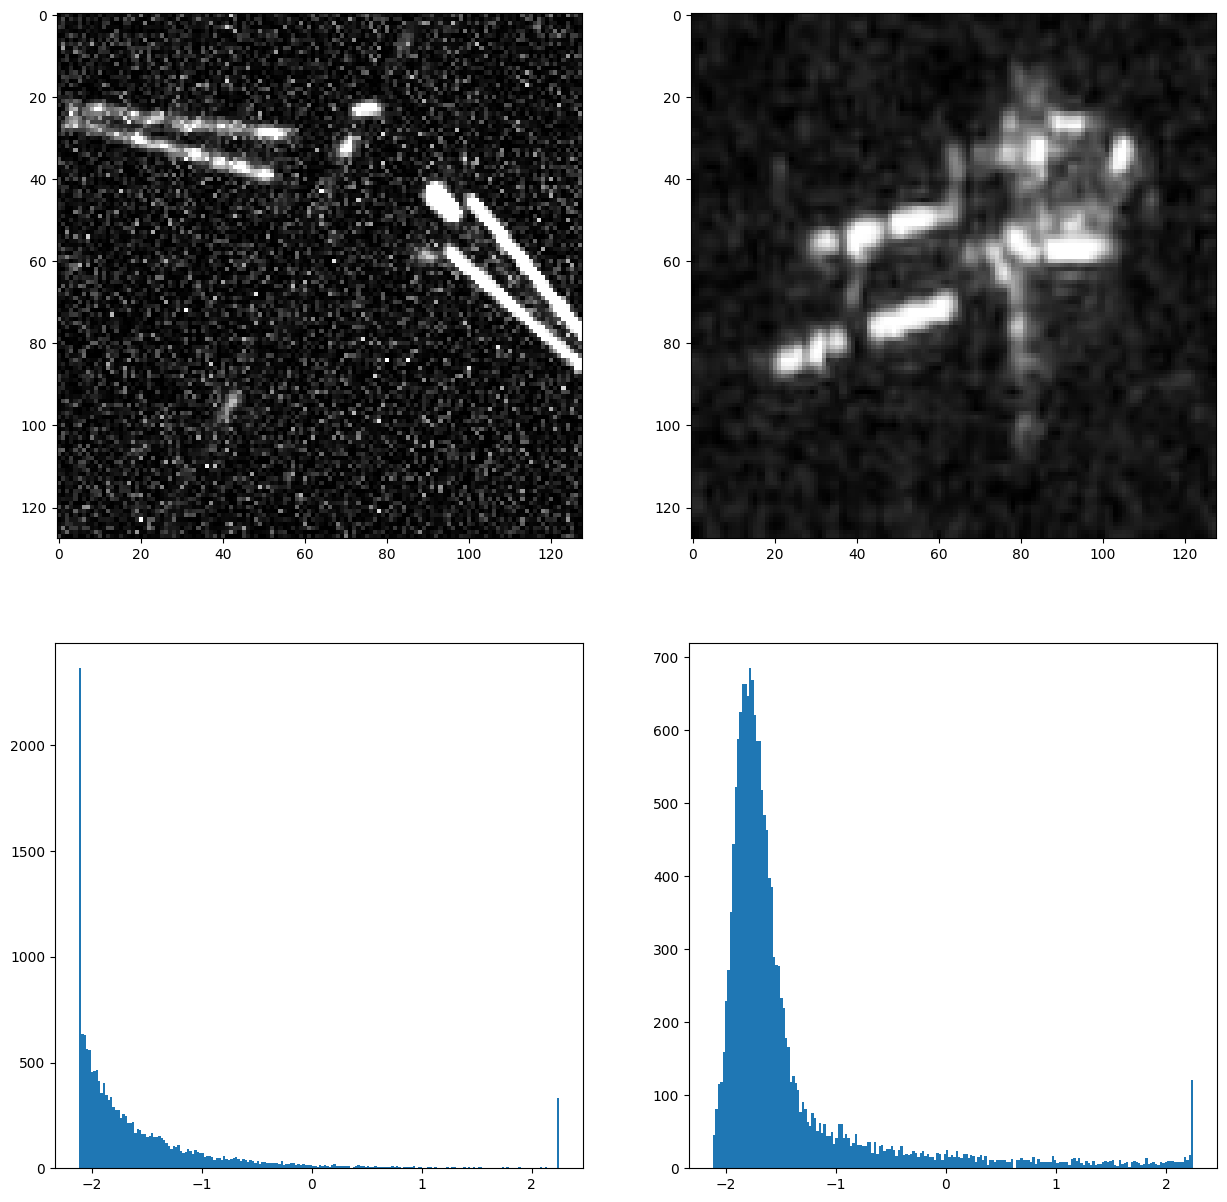

In [542]:
fig, ax = plt.subplots(2,2, figsize = (15,15))
ax[0,0].imshow(train_im[2,0], 'gray')
ax[0,1].imshow(val_im[5,0], 'gray')
ax[1,0].hist(train_im[2,0].ravel(), bins = 200)
ax[1,1].hist(val_im[5,0].ravel(), bins = 200)
plt.show()

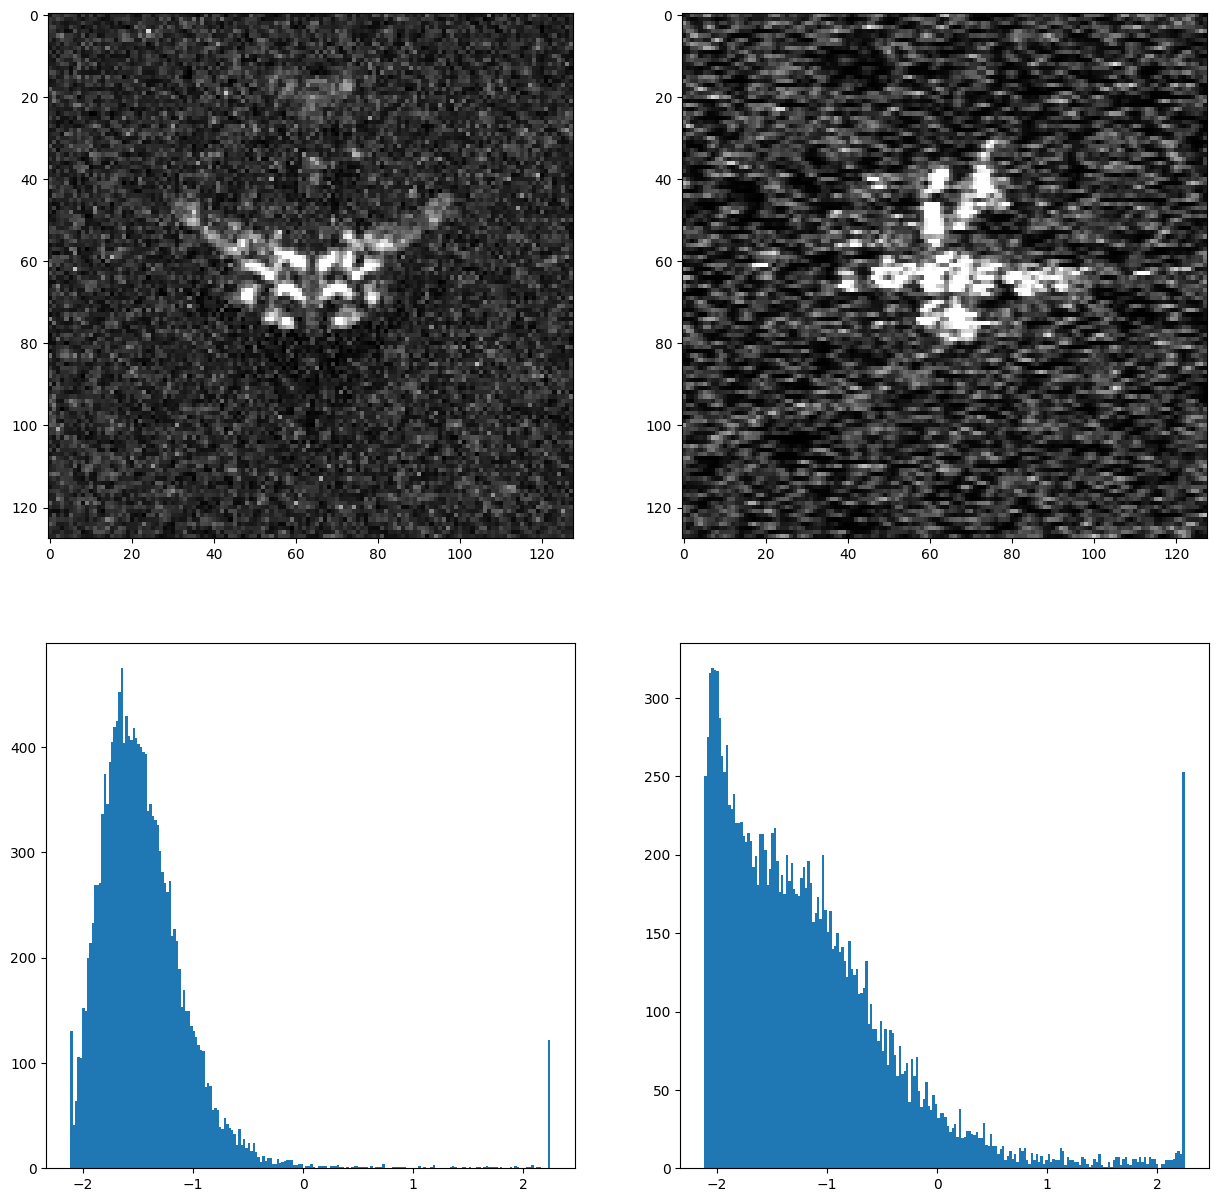

In [543]:
fig, ax = plt.subplots(2,2, figsize = (15,15))
ax[0,0].imshow(train_im[15,0], 'gray')
ax[0,1].imshow(val_im[-2,0], 'gray')
ax[1,0].hist(train_im[8,0].ravel(), bins = 200)
ax[1,1].hist(val_im[-2,0].ravel(), bins = 200)
plt.show()

In [544]:
# defining the model

model = models.mobilenet_v3_small(weights= models.MobileNet_V3_Small_Weights.IMAGENET1K_V1)

for param in model.parameters():
    param.requires_grad = False
num_features = model.classifier[-1].in_features
model.classifier[-1] = nn.Linear(num_features, num_classes)
model.classifier[2] = nn.Dropout(p=0.6, inplace=True)
for param in model.classifier.parameters():
    param.requires_grad =True

model.to(device)

MobileNetV3(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(16, eps=0.001, momentum=0.01, affine=True, track_running_stats=True)
      (2): Hardswish()
    )
    (1): InvertedResidual(
      (block): Sequential(
        (0): Conv2dNormActivation(
          (0): Conv2d(16, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), groups=16, bias=False)
          (1): BatchNorm2d(16, eps=0.001, momentum=0.01, affine=True, track_running_stats=True)
          (2): ReLU(inplace=True)
        )
        (1): SqueezeExcitation(
          (avgpool): AdaptiveAvgPool2d(output_size=1)
          (fc1): Conv2d(16, 8, kernel_size=(1, 1), stride=(1, 1))
          (fc2): Conv2d(8, 16, kernel_size=(1, 1), stride=(1, 1))
          (activation): ReLU()
          (scale_activation): Hardsigmoid()
        )
        (2): Conv2dNormActivation(
          (0): Conv2d(16, 16, kernel_size=(1, 1), 

In [545]:
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
param_to_update = [p for p in model.parameters() if p.requires_grad]
optimizer = optim.Adam(param_to_update, lr = learning_rate, weight_decay = 5e-3)

In [546]:
# training Loop 
# classes = TU - 0, helicopter -2
from sklearn.metrics import confusion_matrix
class_names = ["TU", "Civilian", "Helicopter", 'transporter']
best_val_acc = 0.0
checkpoint = os.path.join(checkpoint_dir, checkpoint_name)
alpha = 0.1
w_acc = 0.7
w_loss  =0.3
warmup_epochs = 10
best_epoch = 0
best_score = -10
patience = 15
delta = 1e-2
epochs_no_improve = 0
for epoch in range(num_epochs):
    model.train()

    running_loss = 0.0
    correct  =  0
    total = 0
    val_run_loss = 0

    for images, labels  in train_loader:
        images, labels = images.to(device) , labels.to(device)
        optimizer.zero_grad()

        output = model(images)
        loss = criterion(output, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()*images.size(0)
        _, predicted = torch.max(output.data, 1)
        total += labels.size(0)
        correct += (predicted==labels).sum().item()
    train_acc = 100*correct/total
    train_loss = running_loss/len(train_loader.dataset)
    writer.add_scalar("Train/loss", train_loss, epoch)
    writer.add_scalar("Train/Accuracy", train_acc , epoch)


    model.eval()
    val_correct = 0
    val_total = 0
    val_loss = 0
    ema_acc = 0
    all_pred = []
    all_labels = []
    with torch.no_grad():
        for images, labels in val_loader:
            images ,labels = images.to(device), labels.to(device)
            outputs = model(images)
            v_loss = criterion(outputs, labels)
            val_run_loss += v_loss.item()*images.size(0)
            _ , predicted = torch.max(outputs.data,1)
            val_total += labels.size(0)
            val_correct += (predicted==labels).sum().item()
            all_pred.append(predicted.cpu().numpy())
            all_labels.append(labels.cpu().numpy())
    all_pred = np.concatenate(all_pred)
    all_labels = np.concatenate(all_labels)
    cm = confusion_matrix(all_labels, all_pred)
    num_classes = cm.shape[0]
    total = cm.sum()
    
    val_loss = val_run_loss/len(val_loader.dataset)
    val_acc = 100*val_correct/val_total
    if epoch ==0:
        ema_acc = val_acc
    else:
        ema_acc = alpha*val_acc +(1-alpha)*ema_acc
    score = w_acc*ema_acc - w_loss*v_loss
    writer.add_scalar("Val/loss", val_loss, epoch)
    writer.add_scalar("Val/Accuracy", val_acc, epoch)
    writer.add_scalar("Val/ema_accuracy_0.2", ema_acc,epoch)
    writer.add_scalar("model/score", score, epoch)

    print(f"Epoch {epoch}/{num_epochs}")
    for i in range(num_classes):
        TP = cm[i,i]
        FN = cm[i, :].sum() - TP
        FP = cm[:, i].sum() - TP
        TN = total - (TP + FN + FP)

        TPR = TP / (TP + FN) if (TP + FN) > 0 else 0
        FPR = FP / (FP + TN) if (FP + TN) > 0 else 0
        writer.add_scalar(f"TPR/{class_names[i]}", TPR*100, epoch)
        writer.add_scalar(f"FPR/{class_names[i]}", FPR*100, epoch)
        print(f"{class_names[i]}: TPR={TPR:.3f}, FPR={FPR:.3f}")
    print(f"Train Loss: {train_loss:.4f}, Train acc: {train_acc: .2f}%")
    print(f"Val Loss {val_loss:.2f} Val Acc: {val_acc:.2f}%")
    if epoch>= warmup_epochs:
        if score > best_score+ delta:
            best_score=score
            best_val_acc = val_acc
            best_epoch = epoch
            torch.save(model.state_dict(), checkpoint)
            print("saving model at", best_epoch)
            epochs_no_improve = 0
        else:
            epochs_no_improve +=1
    if epochs_no_improve >= patience:
        print(f"Early Stop at epoch {epoch}")
        break
    

print("training Complete. epoch accuracy, loss :",best_epoch, best_val_acc, val_loss)




Epoch 0/100
TU: TPR=0.000, FPR=0.000
Civilian: TPR=0.000, FPR=0.295
Helicopter: TPR=0.000, FPR=0.000
transporter: TPR=0.818, FPR=0.763
Train Loss: 1.0478, Train acc:  61.29%
Val Loss 1.43 Val Acc: 22.22%
Epoch 1/100
TU: TPR=0.000, FPR=0.000
Civilian: TPR=0.000, FPR=0.328
Helicopter: TPR=0.000, FPR=0.000
transporter: TPR=0.773, FPR=0.746
Train Loss: 0.6790, Train acc:  85.06%
Val Loss 1.55 Val Acc: 20.99%
Epoch 2/100
TU: TPR=0.000, FPR=0.000
Civilian: TPR=0.000, FPR=0.262
Helicopter: TPR=0.000, FPR=0.000
transporter: TPR=0.818, FPR=0.797
Train Loss: 0.6263, Train acc:  88.71%
Val Loss 1.66 Val Acc: 22.22%
Epoch 3/100
TU: TPR=0.000, FPR=0.000
Civilian: TPR=0.000, FPR=0.213
Helicopter: TPR=0.000, FPR=0.000
transporter: TPR=0.864, FPR=0.831
Train Loss: 0.5662, Train acc:  92.35%
Val Loss 1.70 Val Acc: 23.46%
Epoch 4/100
TU: TPR=0.053, FPR=0.000
Civilian: TPR=0.000, FPR=0.066
Helicopter: TPR=0.000, FPR=0.000
transporter: TPR=0.909, FPR=0.949
Train Loss: 0.5566, Train acc:  91.65%
Val Loss 1

KeyboardInterrupt: 